In [20]:
# This script trains the DeepHit model on the provided dataset and 
# evaluates its performance using the C-index at a specified time horizon.
# It also includes a permutation feature importance analysis to identify
# which features are most influential for the model's predictions at that horizon.
import os
import random
import numpy as np
import tensorflow as tf
from trainDeepHit import *
from sklearn.model_selection import KFold
from utils_eval import c_index
import pandas as pd
import ImportDatabase as impt
from ClassDeepHit import DeepHitPlus
from sklearn.model_selection import train_test_split
from dotenv import load_dotenv
from pathlib import Path
from lifelines import AalenJohansenFitter
import matplotlib.pyplot as plt

load_dotenv()

True

In [21]:
SEED = 321

num_Event = 2
eval_time = 12
CV_ITERATION = 5
eval_horizon = 12  # same as eval_time, used for C-index evaluation

def setSeed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["TF_DETERMINISTIC_OPS"] = "1"   # deterministic TF ops
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

setSeed(SEED)

In [22]:
# ==================================================
# Load data
# ==================================================
data_dir = Path(os.getenv("DATA_DIR"))
path = data_dir / "Region_Sthlm_Gotland_model_data_binary.csv"

x_dim, (data, time, label), (mask1, mask2) = impt.import_dataset(path,time_scale=1.2)

# Normalize age and log-transform certain features
data[:, 0] = (data[:, 0] - data[:, 0].mean()) / data[:, 0].std()

for j in range(data.shape[1] - 3, data.shape[1]): 
    data[:, j] = np.log1p(data[:, j])
    data[:, j] = (data[:, j] - data[:, j].mean()) / data[:, j].std()

# --------------------------------------------------
# Ensure TensorFlow-compatible dtypes
# --------------------------------------------------
data   = data.astype(np.float32)
mask1  = mask1.astype(np.float32)
mask2  = mask2.astype(np.float32)
time   = time.astype(np.float32)
label  = label.astype(np.int32)   


In [23]:
# ==================================================
# Train / Validation split
# ==================================================
kf = KFold(n_splits=CV_ITERATION, shuffle=True, random_state=SEED)
splits = list(kf.split(data))
for i in range(CV_ITERATION):
    tf.keras.backend.clear_session()
    setSeed(SEED)
    train_index, val_index = splits[i]

    tr_data     = data[train_index]
    tr_time     = time[train_index]
    tr_label    = label[train_index]
    tr_mask1    = mask1[train_index]
    tr_mask2    = mask2[train_index]

    va_data     = data[val_index]
    va_time     = time[val_index]
    va_label    = label[val_index]
    va_mask1    = mask1[val_index]
    va_mask2    = mask2[val_index]
    # ==================================================
    # Model definition
    # ==================================================
    num_bins = mask2.shape[1]   # T (time bins)

    model = DeepHitPlus(
        num_event=num_Event,
        num_bins=num_bins,
        shared_layers=(30, 15, 5),
        MR_layers=[5, 10],
        CR_layers=(5, 10),
        dropout=0.25   
    )

    model = TrainDeepHit(model, tr_data, tr_mask1, tr_mask2, tr_time, tr_label,
                    eval_time = [12], 
                    test_size = 0.2, max_epochs = 100, batch_size = 128, learning_rate = 1e-3, alpha=1.0, beta=1.0)

    print("\n===== TRAINING FINISHED =====\n")


    def compute_cindex_at_time(model, data, time, label, eval_horizon):
        """
        Compute event-specific C-index at a given time horizon.
        """
        pred = model.call(data, training=False).numpy()  # (N, K, T)

        if eval_horizon >= pred.shape[2]:
            raise ValueError("eval_horizon exceeds num_Category")

        # Risk up to horizon
        risk = np.sum(pred[:, :, :(eval_horizon + 1)], axis=2)  # (N, K)

        cidx = np.zeros(num_Event)
        for k in range(num_Event):
            cidx[k] = c_index(
                risk[:, k],
                time,
                (label[:, 0] == k + 1).astype(int),
                eval_horizon
            )
        return cidx

    baseline_cindex = compute_cindex_at_time(
        model,
        va_data,
        va_time,
        va_label,
        eval_horizon
    )

    print(f"Fold {i+1} C-index: {baseline_cindex[0]:.3f} (competing event: {baseline_cindex[1]:.3f})")


===== START TRAINING =====

Epoch 000 | Train 4.4840 (LL 2.0990, Rank 2.3850) | Test 44.7273 | Test C-index 0.5880 (competing event: 0.5034)
Epoch 001 | Train 3.1465 (LL 1.0899, Rank 2.0566) | Test 34.7802 | Test C-index 0.8262 (competing event: 0.8111)
Epoch 002 | Train 2.3675 (LL 0.4960, Rank 1.8715) | Test 36.8325 | Test C-index 0.8252 (competing event: 0.8212)
Epoch 003 | Train 2.1186 (LL 0.3514, Rank 1.7672) | Test 34.2603 | Test C-index 0.8423 (competing event: 0.8233)
Epoch 004 | Train 2.0291 (LL 0.3629, Rank 1.6663) | Test 32.7038 | Test C-index 0.8405 (competing event: 0.8238)
Epoch 005 | Train 1.9241 (LL 0.3385, Rank 1.5856) | Test 31.8670 | Test C-index 0.8440 (competing event: 0.8243)
Epoch 006 | Train 1.8322 (LL 0.3287, Rank 1.5035) | Test 31.0012 | Test C-index 0.8454 (competing event: 0.8277)
Epoch 007 | Train 1.7910 (LL 0.3283, Rank 1.4627) | Test 30.4121 | Test C-index 0.8486 (competing event: 0.8260)
Epoch 008 | Train 1.7162 (LL 0.3214, Rank 1.3948) | Test 30.1991 | 

In [24]:
# Final traing of the model after cross-validation, with the best hyperparameters, on the entire dataset
model = DeepHitPlus(
    num_event=num_Event,
    num_bins=num_bins,
    shared_layers=(30, 15, 5),
    MR_layers=[5, 10],
    CR_layers=(5, 10),
    dropout=0.25   
)

model = TrainDeepHit(model, data, mask1, mask2, time, label,
                eval_time = [12], 
                test_size = 0.2, max_epochs = 100, batch_size = 128, learning_rate = 1e-3, alpha=1.0, beta=1.0)



===== START TRAINING =====

Epoch 000 | Train 4.2338 (LL 1.9183, Rank 2.3155) | Test 49.6096 | Test C-index 0.7037 (competing event: 0.6485)
Epoch 001 | Train 2.7200 (LL 0.7970, Rank 1.9230) | Test 44.5555 | Test C-index 0.8019 (competing event: 0.8097)
Epoch 002 | Train 2.0687 (LL 0.4134, Rank 1.6553) | Test 41.4377 | Test C-index 0.8072 (competing event: 0.8315)
Epoch 003 | Train 1.8776 (LL 0.3559, Rank 1.5217) | Test 39.7105 | Test C-index 0.8137 (competing event: 0.8316)
Epoch 004 | Train 1.7758 (LL 0.3375, Rank 1.4384) | Test 39.7299 | Test C-index 0.8125 (competing event: 0.8393)
Epoch 005 | Train 1.7000 (LL 0.3356, Rank 1.3643) | Test 39.2331 | Test C-index 0.8142 (competing event: 0.8307)
Epoch 006 | Train 1.6626 (LL 0.3204, Rank 1.3421) | Test 38.7951 | Test C-index 0.8218 (competing event: 0.8270)
Epoch 007 | Train 1.6202 (LL 0.3261, Rank 1.2941) | Test 39.8083 | Test C-index 0.8182 (competing event: 0.8288)
Epoch 008 | Train 1.5224 (LL 0.3179, Rank 1.2044) | Test 40.7602 | 

In [25]:
def permutation_feature_importance(
    model,
    x_val,
    time_val,
    label_val,
    eval_horizon,
    n_repeats=5
):
    """
    Permutation feature importance using drop in C-index.
    Returns array of shape (num_Event, num_features).
    """
    n_features = x_val.shape[1]
    baseline = compute_cindex_at_time(
        model, x_val, time_val, label_val, eval_horizon
    )
    
    importance = np.zeros((num_Event, n_features))

    for j in range(n_features):
        drops = []

        for _ in range(n_repeats):
            x_perm = x_val.copy()
            perm_idx = np.random.permutation(x_perm.shape[0])
            x_perm[:, j] = x_perm[perm_idx, j]

            cidx_perm = compute_cindex_at_time(
                model, x_perm, time_val, label_val, eval_horizon
            )

            drops.append(baseline - cidx_perm)

        importance[:, j] = np.mean(drops, axis=0)

        if j % 10 == 0:
            print(f"PFI done for feature {j}/{n_features}")

    return importance

pfi = permutation_feature_importance(
    model=model,
    x_val=va_data,
    time_val=va_time,
    label_val=va_label,
    eval_horizon=eval_horizon,
    n_repeats=3
)

print("PFI shape:", pfi.shape)  # (num_Event, num_features)

# Top 10 features per event
for k in range(num_Event):
    top_idx = np.argsort(-pfi[k])[:10]
    print(f"\nTop features for event {k+1}:")
    print(top_idx)
    print(pfi[k, top_idx])


PFI done for feature 0/88
PFI done for feature 10/88
PFI done for feature 20/88


KeyboardInterrupt: 

In [26]:
def bootstrap_cindex_at_time(
    model,
    data,
    time,
    label,
    eval_horizon,
    n_bootstrap=1000,
    seed=42
):
    """
    Bootstrap 95% confidence intervals for event-specific C-index.

    Parameters
    ----------
    model : trained DeepHit model
    data : validation features
    time : validation follow-up times
    label : validation labels
    eval_horizon : evaluation time horizon
    n_bootstrap : number of bootstrap samples
    seed : random seed

    Returns
    -------
    baseline : (num_Event,)
        Original C-index on the validation set.

    ci_lower : (num_Event,)
        Lower 95% confidence interval.

    ci_upper : (num_Event,)
        Upper 95% confidence interval.

    bootstrap_scores : (n_bootstrap, num_Event)
        All bootstrap C-index values.
    """

    rng = np.random.default_rng(seed)
    n = len(time)

    # Original estimate
    baseline = compute_cindex_at_time(
        model,
        data,
        time,
        label,
        eval_horizon
    )

    bootstrap_scores = np.zeros((n_bootstrap, num_Event))

    for b in range(n_bootstrap):

        # Sample patients with replacement
        idx = rng.choice(n, size=n, replace=True)

        data_b = data[idx]
        time_b = time[idx]
        label_b = label[idx]

        bootstrap_scores[b] = compute_cindex_at_time(
            model,
            data_b,
            time_b,
            label_b,
            eval_horizon
        )

    ci_lower = np.percentile(bootstrap_scores, 2.5, axis=0)
    ci_upper = np.percentile(bootstrap_scores, 97.5, axis=0)

    return baseline, ci_lower, ci_upper, bootstrap_scores

In [27]:
    
path = np.array([
    data_dir / "Region_Uppsala_Örebro_model_data_binary.csv",
    data_dir / "Region_Väst_model_data_binary.csv",
    data_dir / "Region_Syd_model_data_binary.csv",
    data_dir / "Region_Sydöstra_model_data_binary.csv",
    data_dir / "Region_Norr_model_data_binary.csv"]
    )
Region_names = {
    0: "Region Uppsala_Örebro",
    1: "Region Väst",
    2: "Region Syd",
    3: "Region Sydöstra",
    4: "Region Norr"
}

for i in range(len(path)):

    x_dim, (data, time, label), (mask1, mask2) = impt.import_dataset(path[i],time_scale=1.2)

    num_Category = mask2.shape[1]   # T (time bins)
    eval_time = [12]
    data[:, 0] = (data[:, 0] - data[:, 0].mean()) / data[:, 0].std()

    for j in range(data.shape[1] - 3, data.shape[1]):
        data[:, j] = np.log1p(data[:, j])
        data[:, j] = (data[:, j] - data[:, j].mean()) / data[:, j].std()

    data   = data.astype(np.float32)
    mask1  = mask1.astype(np.float32)
    mask2  = mask2.astype(np.float32)
    time   = time.astype(np.float32)
    label  = label.astype(np.int32) 

    baseline, ci_lower, ci_upper, bootstrap_scores = bootstrap_cindex_at_time(
    model,
    data,
    time,
    label,
    eval_horizon,
    n_bootstrap=5,
    seed=42
)

    print(f"{Region_names[i]:<25}\t"
          f"main risk: {baseline[0]:.3f} (95% CI: {ci_lower[0]:.3f} - {ci_upper[0]:.3f})\t"
          f"competing risk: {baseline[1]:.3f} (95% CI: {ci_lower[1]:.3f} - {ci_upper[1]:.3f})")
    '''
    pred = model.call(data, training=False).numpy()  # (N, K, T)
    resultfeat = np.zeros([num_Event, len(eval_time)])

    for t, t_time in enumerate(eval_time):
        eval_horizon = int(t_time)

        if eval_horizon >= num_Category:
            print('ERROR: evaluation horizon is out of range')
            resultfeat[:, t] = -1
        else:
            # calculate F(t | x, Y, t >= t_M) = \sum_{t_M <= \tau < t} P(\tau | x, Y, \tau > t_M)
            risk = np.sum(pred[:,:,:(eval_horizon+1)], axis=2) #risk score until eval_time

            # Calculate permutation importance for each eval horizon and event
            for k in range(num_Event):
                resultfeat[k, t] = c_index(risk[:,k], time, (label[:,0] == k+1).astype(int), eval_horizon) #-1 for no event (not comparable)
                
                #result.loc[k+1, feat, perm_iter, "Delta t = " + "{:03d}".format(t_time)] = result1[k,t] - resultfeat[k,t]
                # since we compare risk_scores, the true label is that event occurs before time horizon
                #result.loc[k+1, feat, perm_iter, "Delta t = " + "{:03d}".format(t_time)] = result1[k,t] - resultfeat[k,t]
                # since we compare risk_scores, the true label is that event occurs before time horizon
    print(
        f"{Region_names[i]:<25}\t"
        f"main risk: {resultfeat[0,0]:.3f}\t"
        f"competing risk: {resultfeat[1,0]:.3f}"
    )'''


<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\s'
/var/folders/vj/tlj0y71x381bb5cfc_8ylv2nf7_f43/T/ipykernel_71487/1404812358.py:58: SyntaxWarning: invalid escape sequence '\s'
  # calculate F(t | x, Y, t >= t_M) = \sum_{t_M <= \tau < t} P(\tau | x, Y, \tau > t_M)


Region Uppsala_Örebro   	main risk: 0.849 (95% CI: 0.829 - 0.859)	competing risk: 0.821 (95% CI: 0.796 - 0.836)
Region Väst             	main risk: 0.841 (95% CI: 0.827 - 0.849)	competing risk: 0.836 (95% CI: 0.806 - 0.843)
Region Syd               	main risk: 0.827 (95% CI: 0.807 - 0.839)	competing risk: 0.819 (95% CI: 0.797 - 0.830)
Region Sydöstra         	main risk: 0.833 (95% CI: 0.816 - 0.855)	competing risk: 0.843 (95% CI: 0.782 - 0.858)
Region Norr              	main risk: 0.796 (95% CI: 0.796 - 0.819)	competing risk: 0.815 (95% CI: 0.784 - 0.830)


/Users/mehman/Projects/DeepHit_updated/venv/lib/python3.13/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
/Users/mehman/Projects/DeepHit_updated/venv/lib/python3.13/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(


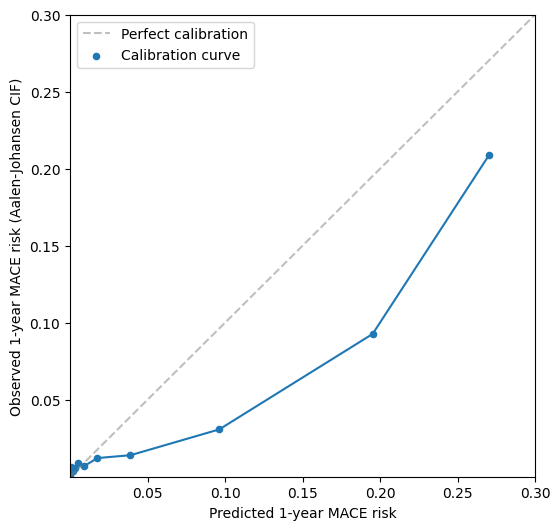

In [9]:
# ==================================================
# DeepHit competing-risk calibration at 12 months
# ==================================================
import matplotlib.pyplot as plt
from lifelines import AalenJohansenFitter
# ==================================================
# Load data
# ==================================================
data_dir = Path(os.getenv("DATA_DIR"))
path = data_dir / "Region_sthlm_Gotland_model_data_binary.csv"

x_dim, (data, time, label), (mask1, mask2) = impt.import_dataset(path,time_scale=1.2)

# Normalize age and log-transform certain features
data[:, 0] = (data[:, 0] - data[:, 0].mean()) / data[:, 0].std()

for j in range(data.shape[1] - 3, data.shape[1]): 
    data[:, j] = np.log1p(data[:, j])
    data[:, j] = (data[:, j] - data[:, j].mean()) / data[:, j].std()

# --------------------------------------------------
# Ensure TensorFlow-compatible dtypes
# --------------------------------------------------
data   = data.astype(np.float32)
mask1  = mask1.astype(np.float32)
mask2  = mask2.astype(np.float32)
time   = time.astype(np.float32)
label  = label.astype(np.int32)   

# ==================================================
# 1. Predict from DeepHit model
# ==================================================

pred = model.call(data, training=False).numpy()

# Expected shape:
# (patients, events, time_bins)

# ==================================================
# 2. Extract predicted MACE cumulative incidence
# ==================================================

# DeepHit event index:
# 0 = MACE
# 1 = competing event

mace_index = 0

# Sum probabilities up to 12-month horizon
risk_1yr = np.sum(
    pred[:, mace_index, :eval_time],
    axis=1
)

# ==================================================
# 3. Create evaluation dataframe
# ==================================================

eval_df = pd.DataFrame({

    "time": time.ravel(),

    # Keep original competing-risk labels:
    # 0 = censored
    # 1 = MACE
    # 2 = competing event
    "event": label.ravel(),

    "risk_1yr": risk_1yr

})

# ==================================================
# 4. Create predicted risk deciles
# ==================================================

eval_df["risk_decile"] = pd.qcut(
    eval_df["risk_1yr"],
    q=15,
    labels=False,
    duplicates="drop"
)

# ==================================================
# 5. Calculate observed cumulative incidence
#    using Aalen-Johansen estimator
# ==================================================

aj = AalenJohansenFitter()

calibration_results = []


for decile, group in eval_df.groupby("risk_decile"):


    # Mean predicted risk in this decile
    predicted = group["risk_1yr"].mean()


    # Fit competing-risk CIF
    aj.fit(
        durations=group["time"],
        event_observed=group["event"],
        event_of_interest=1   # observed MACE
    )

    cif = aj.cumulative_density_

    # CIF at 12 months
    available_times = cif.index[cif.index <= eval_time]


    if len(available_times) > 0:

        observed = cif.loc[
            available_times[-1]
        ].values[0]

    else:

        observed = 0



    calibration_results.append({

        "decile": int(decile)+1,

        "n": len(group),

        "predicted_risk": predicted,

        "observed_risk": observed

    })


calibration_results = pd.DataFrame(
    calibration_results
)


# ==================================================
# 6. Plot calibration curve
# ==================================================

plt.figure(figsize=(6,6))

max_value = calibration_results[
    ["predicted_risk", "observed_risk"]
].max().max()
max_value = 0.3

plt.plot(
    [0, max_value],
    [0, max_value],
    "--",
    label="Perfect calibration",
    color="gray",
    alpha=0.5
)

plt.scatter(
    calibration_results["predicted_risk"],
    calibration_results["observed_risk"],
    color="#1f77b4",
    s=20,
    label="Calibration curve"
)

plt.plot(
    calibration_results["predicted_risk"],
    calibration_results["observed_risk"],
    "-",
    color="#1f77b4"
)

plt.xlabel(
    "Predicted 1-year MACE risk"
)

plt.ylabel(
    "Observed 1-year MACE risk (Aalen-Johansen CIF)"
)


plt.xlim(2e-6, max_value)
plt.ylim(2e-6, max_value)
#plt.xscale("log")
#plt.yscale("log")

plt.legend()
plt.grid(False)

plt.show()

In [10]:
# ==================================================
# Calibration slope and intercept
# ==================================================

import statsmodels.api as sm


# Avoid log(0) and log(1)
eps = 1e-16


# Convert predicted probability to log-odds
eval_df["logit_predicted_risk"] = np.log(
    (eval_df["risk_1yr"] + eps) /
    (1 - eval_df["risk_1yr"] + eps)
)


# Define observed 1-year MACE outcome
# MACE happened AND occurred before/equal to 12 months
eval_df["MACE_1yr"] = (
    (eval_df["event"] == 1) &
    (eval_df["time"] <= eval_time)
).astype(int)



# Logistic calibration model
# logit(observed MACE) = intercept + slope*logit(predicted risk)

X = sm.add_constant(
    eval_df["logit_predicted_risk"]
)

y = eval_df["MACE_1yr"]


calibration_model = sm.Logit(
    y,
    X
).fit()



# Extract values

calibration_intercept = (
    calibration_model.params["const"]
)

calibration_slope = (
    calibration_model.params["logit_predicted_risk"]
)


print("--------------------------------")
print("Calibration intercept:",
      calibration_intercept)

print("Calibration slope:",
      calibration_slope)

print("--------------------------------")

Optimization terminated successfully.
         Current function value: 0.092453
         Iterations 10
--------------------------------
Calibration intercept: -1.0181691522408847
Calibration slope: 0.7685431765652021
--------------------------------


--------------------------------
Brier score at 12 months: 0.02455318055751616
Integrated Brier Score: 0.041602127204827595
--------------------------------


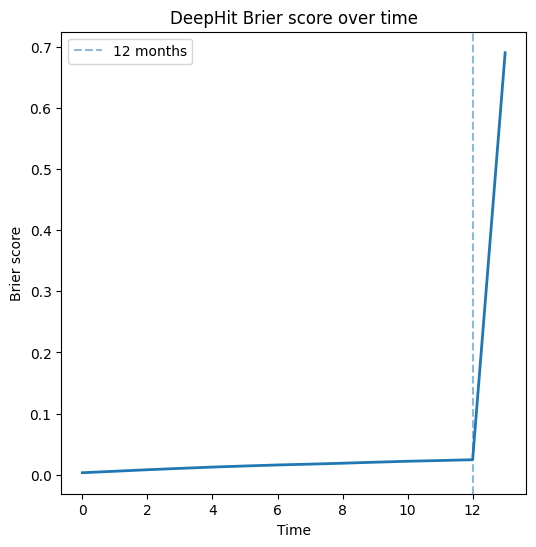

In [ ]:
# ==================================================
# 1. Predictions from DeepHit
# ==================================================

pred = model.call(data, training=False).numpy()

# pred shape:
# (N patients, K events, T time bins)

mace_index = 0


# ==================================================
# 2. Convert DeepHit PMF to cumulative incidence
# ==================================================

# CIF(t) = cumulative sum of event probability over time

mace_cif = np.cumsum(
    pred[:, mace_index, :],
    axis=1
)


# ==================================================
# 3. Define time grid
# ==================================================

# DeepHit time bins
time_grid = np.arange(
    mace_cif.shape[1]
)


# ==================================================
# 4. Brier score calculation
# ==================================================

brier_scores = []


for t in time_grid:

    # predicted probability of MACE by time t
    pred_risk = mace_cif[:, t]


    # Observed outcome at time t
    # MACE occurred before/equal t
    observed = (
        (label.ravel() == 1) &
        (time.ravel() <= t)
    ).astype(int)


    # Ignore competing events for simple Brier estimate
    bs = np.mean(
        (pred_risk - observed) ** 2
    )


    brier_scores.append(bs)



brier_scores = np.array(
    brier_scores
)


# ==================================================
# 5. Brier score at 12 months
# ==================================================

brier_12 = brier_scores[eval_time]


print("--------------------------------")
print("Brier score at 12 months:",
      brier_12)


# ==================================================
# 6. Integrated Brier Score (IBS)
# ==================================================

ibs = np.trapezoid(
    brier_scores,
    time_grid
) / (
    time_grid[-1] - time_grid[0]
)


print("Integrated Brier Score:",
      ibs)

print("--------------------------------")



# ==================================================
# 7. Plot Brier score over time
# ==================================================

plt.figure(figsize=(6,6))

plt.plot(
    time_grid,
    brier_scores,
    linewidth=2
)

plt.axvline(
    eval_time,
    linestyle="--",
    alpha=0.5,
    label="12 months"
)


plt.xlabel("Time")
plt.ylabel("Brier score")

plt.title(
    "DeepHit Brier score over time"
)

plt.legend()

plt.show()

   threshold  DeepHit_model  Treat_all  Treat_none
0      0.001       0.022918   0.023845         0.0
1      0.005       0.019949   0.019921         0.0
2      0.010       0.017824   0.014971         0.0
3      0.030       0.012001  -0.005339         0.0
4      0.050       0.007277  -0.026504         0.0
5      0.075       0.002452  -0.054247         0.0
6      0.100      -0.001090  -0.083532         0.0


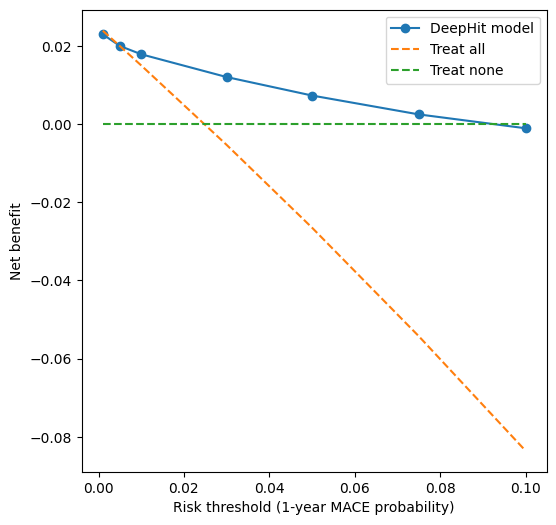

In [193]:
# ==================================================
# 1. Define observed 1-year MACE outcome
# ==================================================

eval_df["MACE_1yr"] = (
    (eval_df["event"] == 1) &
    (eval_df["time"] <= eval_time)
).astype(int)



# ==================================================
# 2. Net benefit function
# ==================================================

def calculate_net_benefit(
    y_true,
    predicted_risk,
    threshold
):

    # classify patients as high risk
    predicted_positive = (
        predicted_risk >= threshold
    )


    TP = np.sum(
        predicted_positive & (y_true == 1)
    )

    FP = np.sum(
        predicted_positive & (y_true == 0)
    )


    N = len(y_true)


    net_benefit = (
        TP / N
        -
        (FP / N) *
        (threshold / (1 - threshold))
    )


    return net_benefit



# ==================================================
# 3. Thresholds
# ==================================================

thresholds = np.array([
    0.001,
    0.005,
    0.01,
    0.03,
    0.05,
    0.075,
    0.10
])


y_true = eval_df["MACE_1yr"].values

predicted_risk = eval_df["risk_1yr"].values



# ==================================================
# 4. Model net benefit
# ==================================================

model_nb = []


for t in thresholds:

    nb = calculate_net_benefit(
        y_true,
        predicted_risk,
        t
    )

    model_nb.append(nb)



# ==================================================
# 5. Reference strategies
# ==================================================

N = len(y_true)

prevalence = np.mean(y_true)


# Treat everyone

all_nb = (
    prevalence
    -
    (1 - prevalence)
    *
    (thresholds / (1-thresholds))
)


# Treat nobody

none_nb = np.zeros(
    len(thresholds)
)



# ==================================================
# 6. Results table
# ==================================================

dca_results = pd.DataFrame({

    "threshold": thresholds,

    "DeepHit_model": model_nb,

    "Treat_all": all_nb,

    "Treat_none": none_nb

})


print(dca_results)



# ==================================================
# 7. Plot DCA curve
# ==================================================

plt.figure(figsize=(6,6))


plt.plot(
    thresholds,
    model_nb,
    marker="o",
    label="DeepHit model"
)


plt.plot(
    thresholds,
    all_nb,
    linestyle="--",
    label="Treat all"
)


plt.plot(
    thresholds,
    none_nb,
    linestyle="--",
    label="Treat none"
)

plt.xlabel(
    "Risk threshold (1-year MACE probability)"
)

plt.ylabel(
    "Net benefit"
)

plt.legend()

plt.grid(False)

plt.show()